In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
df = pd.read_csv("../data/heart_disease_reduced.csv")

X = df.drop(columns=["target"])
y = df["target"]


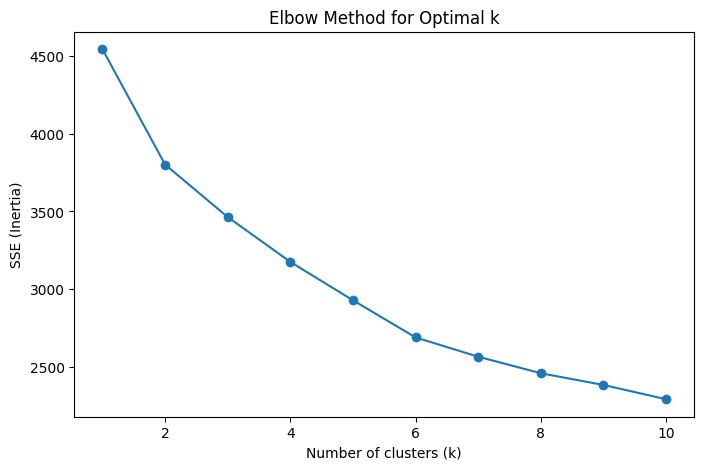

 K-Means Results
Adjusted Rand Index: 0.3547075415650436
Silhouette Score: 0.1584339023402


In [3]:
# 1. K-Means Clustering
# -----------------------------
# Elbow method to find optimal clusters
sse = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, sse, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

# Fit KMeans with 2 clusters (since target is binary: 0/1)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels_kmeans = kmeans.fit_predict(X)

print(" K-Means Results")
print("Adjusted Rand Index:", adjusted_rand_score(y, cluster_labels_kmeans))
print("Silhouette Score:", silhouette_score(X, cluster_labels_kmeans))


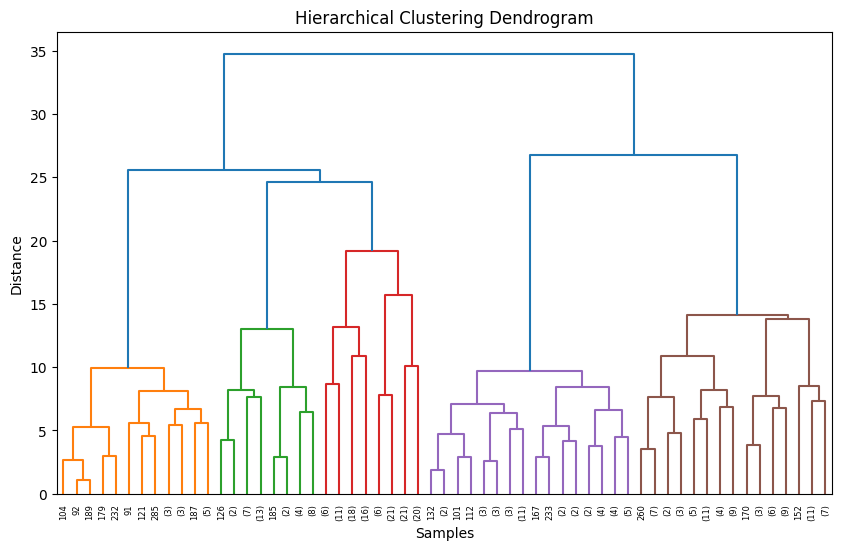


✅ Hierarchical Clustering Results
Adjusted Rand Index: 0.24579701000407989
Silhouette Score: 0.1275918448925468


In [ ]:
# 2. Hierarchical Clustering
# -----------------------------
# Linkage matrix for dendrogram
linked = linkage(X, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode="level", p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Fit Agglomerative Clustering with 2 clusters
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
cluster_labels_hc = hc.fit_predict(X)

print("Hierarchical Clustering Results")
print("Adjusted Rand Index:", adjusted_rand_score(y, cluster_labels_hc))
print("Silhouette Score:", silhouette_score(X, cluster_labels_hc))


In [6]:
# 3. Compare clustering with actual labels
# -----------------------------
comparison = pd.DataFrame({
    "Actual": y,
    "KMeans Cluster": cluster_labels_kmeans,
    "Hierarchical Cluster": cluster_labels_hc
})

print("\nSample Comparison:")
print(comparison.head(10))


Sample Comparison:
   Actual  KMeans Cluster  Hierarchical Cluster
0       0               1                     1
1       1               0                     1
2       1               0                     1
3       0               1                     0
4       0               1                     0
5       0               1                     0
6       1               0                     1
7       0               0                     1
8       1               0                     1
9       1               0                     1
